Continuamos el trabajo para predecir laas Horas Operativas en los próximos 15 días, usando el archivo Datos Agregados.

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from skforecast.recursive import ForecasterRecursive
from sklearn.ensemble import RandomForestRegressor

from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import TimeSeriesFold

In [135]:
# Cargar el CSV
ruta_csv = "../data/Datos_limpios.csv"
df = pd.read_csv(ruta_csv)

# Mostrar las primeras filas y la info general
primeras_filas = df.head()
info_general = df.info()
resumen_estadistico = df.describe()

primeras_filas, resumen_estadistico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731742 entries, 0 to 731741
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    731742 non-null  int64  
 1   Tipo_Equipo                  731742 non-null  int64  
 2   Fabricante                   731742 non-null  int64  
 3   Modelo                       731742 non-null  int64  
 4   Potencia_kW                  731742 non-null  float64
 5   Horas_Recomendadas_Revision  731742 non-null  float64
 6   ID_Orden                     731742 non-null  float64
 7   Fecha                        731742 non-null  object 
 8   Tipo_Mantenimiento           731742 non-null  int64  
 9   Costo_Mantenimiento          731742 non-null  float64
 10  Duracion_Horas               731742 non-null  float64
 11  Ubicacion                    731742 non-null  int64  
 12  ID_Registro                  731742 non-null  int64  
 13 

(   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
 0          1            0           2       6        173.0   
 1          1            0           2       6        173.0   
 2          1            0           2       6        173.0   
 3          1            0           2       6        173.0   
 4          1            0           2       6        173.0   
 
    Horas_Recomendadas_Revision  ID_Orden       Fecha  Tipo_Mantenimiento  \
 0                        913.0       1.0  2021-01-09                   0   
 1                        913.0       1.0  2021-01-10                   0   
 2                        913.0       1.0  2021-01-11                   0   
 3                        913.0       1.0  2021-01-12                   0   
 4                        913.0       1.0  2021-01-13                   0   
 
    Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
 0               3992.0  ...          2            9      69.298440   
 1            

In [136]:
df_filtrado = df[df['ID_Equipo']==1]
df_filtrado

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,...,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Dia,Quincena,Mes,Año,horas_hasta_correctivo
0,1,0,2,6,173.0,913.0,1.0,2021-01-09,0,3992.0,...,2,9,69.298440,6.510735,0,9,1,1,2021,913.0
1,1,0,2,6,173.0,913.0,1.0,2021-01-10,0,3992.0,...,2,10,50.938025,0.338625,20,10,1,1,2021,893.0
2,1,0,2,6,173.0,913.0,1.0,2021-01-11,0,3992.0,...,2,11,24.083260,3.659173,41,11,1,1,2021,872.0
3,1,0,2,6,173.0,913.0,1.0,2021-01-12,0,3992.0,...,2,12,49.907242,7.917208,62,12,1,1,2021,851.0
4,1,0,2,6,173.0,913.0,1.0,2021-01-13,0,3992.0,...,2,13,69.407683,2.912719,63,13,1,1,2021,850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1,0,2,6,173.0,913.0,106.0,2024-12-27,1,769.0,...,2,1457,38.587761,2.748949,808,27,2,12,2024,105.0
1451,1,0,2,6,173.0,913.0,106.0,2024-12-28,1,769.0,...,2,1458,90.397197,5.382844,812,28,2,12,2024,101.0
1452,1,0,2,6,173.0,913.0,106.0,2024-12-29,1,769.0,...,2,1459,21.104524,5.686564,824,29,2,12,2024,89.0
1453,1,0,2,6,173.0,913.0,106.0,2024-12-30,1,769.0,...,2,1460,30.559628,7.948501,828,30,2,12,2024,85.0


In [137]:
df_filtrado_ok = df_filtrado.copy()

Comenzamos con el trabajo de búsqueda de modelo de Serie Temporal para prediccion de Horas_Operativas en los próximos 15 días

In [138]:
df_filtrado_ok['Fecha'] = pd.to_datetime(df_filtrado_ok['Fecha'], format= '%Y-%m-%d')
print(df_filtrado_ok.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1455 entries, 0 to 1454
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID_Equipo                    1455 non-null   int64         
 1   Tipo_Equipo                  1455 non-null   int64         
 2   Fabricante                   1455 non-null   int64         
 3   Modelo                       1455 non-null   int64         
 4   Potencia_kW                  1455 non-null   float64       
 5   Horas_Recomendadas_Revision  1455 non-null   float64       
 6   ID_Orden                     1455 non-null   float64       
 7   Fecha                        1455 non-null   datetime64[ns]
 8   Tipo_Mantenimiento           1455 non-null   int64         
 9   Costo_Mantenimiento          1455 non-null   float64       
 10  Duracion_Horas               1455 non-null   float64       
 11  Ubicacion                    1455 non-null   int

In [139]:
df_filtrado_ok = df_filtrado_ok.sort_values(by='Fecha')
print(df_filtrado_ok.head(5))

   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
0          1            0           2       6        173.0   
1          1            0           2       6        173.0   
2          1            0           2       6        173.0   
3          1            0           2       6        173.0   
4          1            0           2       6        173.0   

   Horas_Recomendadas_Revision  ID_Orden      Fecha  Tipo_Mantenimiento  \
0                        913.0       1.0 2021-01-09                   0   
1                        913.0       1.0 2021-01-10                   0   
2                        913.0       1.0 2021-01-11                   0   
3                        913.0       1.0 2021-01-12                   0   
4                        913.0       1.0 2021-01-13                   0   

   Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
0               3992.0  ...          2            9      69.298440   
1               3992.0  ...         

In [155]:
#Fecha como índice
df_fil_index_data= df_filtrado_ok.set_index('Fecha', inplace= False)

#Eliminar índices duplicados y establecer frecuencia
df_filtrado_limpio= df_fil_index_data[~df_fil_index_data.index.duplicated(keep='first')]
df_filtrado_frec = df_filtrado_limpio.asfreq('D', fill_value=0)
print(df_filtrado_frec.index)


DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-14', '2021-01-15', '2021-01-16',
               '2021-01-17', '2021-01-18',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Fecha', length=1453, freq='D')


In [156]:
# Verificar que un índice temporal está completo
fecha_inicio = df_filtrado_frec.index.min()
fecha_fin = df_filtrado_frec.index.max()
date_range_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq=df_filtrado_frec.index.freq)
print(f"Índice completo: {(df_filtrado_frec.index == date_range_completo).all()}")

Índice completo: True


Fechas train : 2021-01-09 00:00:00 --- 2024-03-16 00:00:00  (n=1163)
Fechas test  : 2024-03-17 00:00:00 --- 2024-12-31 00:00:00  (n=290)


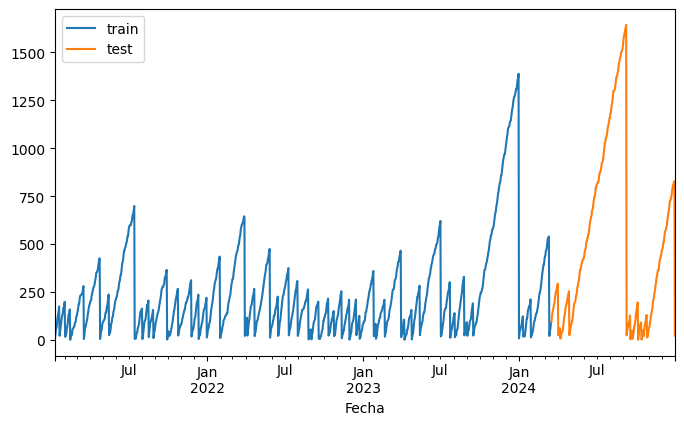

In [161]:
steps = 290
y_train = df_filtrado_frec[:-steps]
y_test  = df_filtrado_frec[-steps:]
print(f"Fechas train : {y_train.index.min()} --- {y_train.index.max()}  (n={len(y_train)})")
print(f"Fechas test  : {y_test.index.min()} --- {y_test.index.max()}  (n={len(y_test)})")
 
fig, ax = plt.subplots(figsize=(8, 4.5))
y_train['Horas_Operativas'].plot(ax=ax, label='train')
y_test['Horas_Operativas'].plot(ax=ax, label='test')
ax.legend();
 

In [162]:
# Crear y entrenar forecaster

forecaster = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=123),
    lags=30
)

target_series = y_train['Horas_Operativas']      # <- pandas Series 1-D
forecaster.fit(y=target_series)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30] 
Window features: None 
Window size: 30 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2021-01-09 00:00:00'), Timestamp('2024-03-16 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-04-30 12:58:49 
Last fit date: 2025-04-30 12:58:51 
Skforecast version: 0.15.1 
Python version: 3.10.14 
Forecaster id: None

In [163]:
# Predicciones
steps = 15
predicciones = forecaster.predict(steps=steps)
predicciones.head(20)

2024-03-17     89.77
2024-03-18     93.80
2024-03-19     88.11
2024-03-20     93.30
2024-03-21    104.97
2024-03-22    110.91
2024-03-23    122.50
2024-03-24    135.82
2024-03-25    146.13
2024-03-26    154.54
2024-03-27    169.40
2024-03-28    180.82
2024-03-29    198.21
2024-03-30    207.60
2024-03-31    221.92
Freq: D, Name: pred, dtype: float64

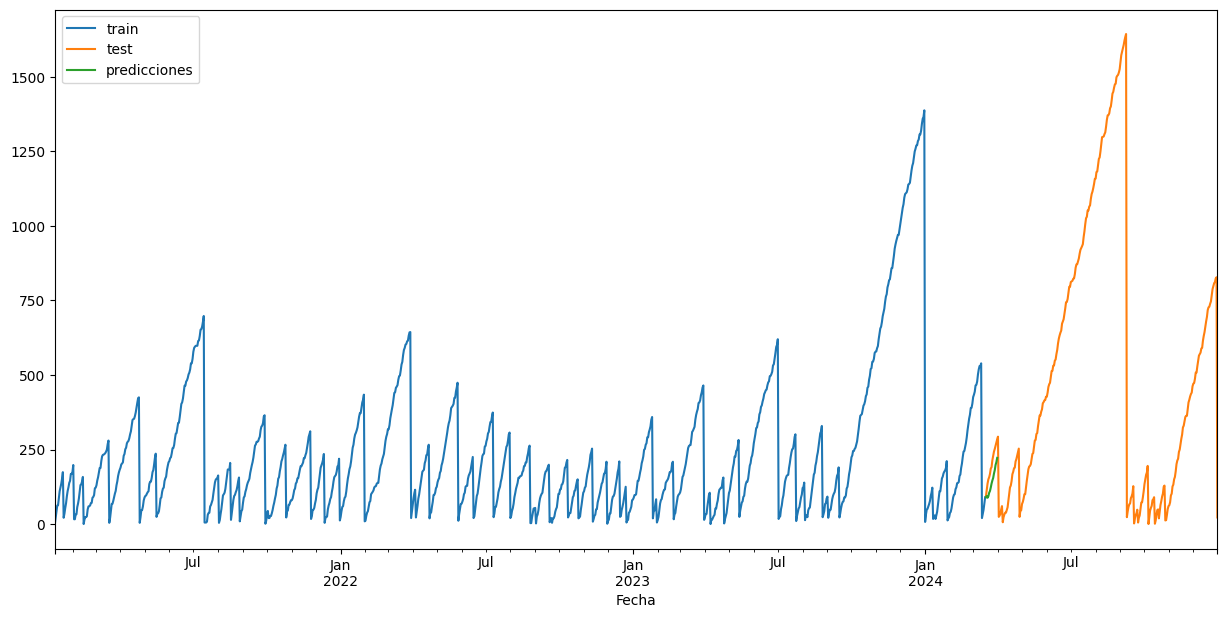

In [164]:
# Gráfico de predicciones vs valores reales

fig, ax = plt.subplots(figsize=(15, 7))
y_train['Horas_Operativas'].plot(ax=ax, label='train')
y_test['Horas_Operativas'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend()

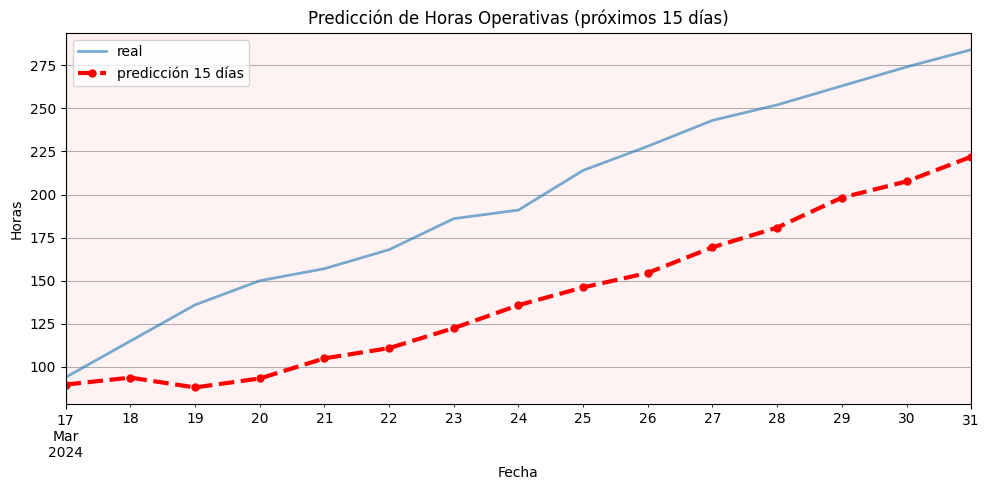

In [166]:
# --- 1. Selecciona la ventana de 15 días -----------------------------
# Punto de arranque = primer día del test (o el que prefieras)
inicio = y_test.index.min()          # «2024-03-06», por ejemplo
fin    = inicio + pd.Timedelta(days=14)

mask_test   = (y_test.index >= inicio) & (y_test.index <= fin)
mask_pred   = (predicciones.index >= inicio) & (predicciones.index <= fin)

y_test_15   = y_test.loc[mask_test, 'Horas_Operativas']
pred_15     = predicciones.loc[mask_pred]

# --- 2. Grafica, resaltando la predicción ----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Serie real
y_test_15.plot(ax=ax,
               label='real',
               linewidth=2,
               alpha=0.6)

# Predicción (más gruesa, color llamativo, marcadores)
pred_15.plot(ax=ax,
             label='predicción 15 días',
             linewidth=3,
             marker='o',
             markersize=5,
             linestyle='--',
             color='red')          # Usa el color que prefieras

# Opcional: sombrear la zona de predicción
ax.axvspan(inicio, fin,
           color='red',
           alpha=0.05)

# Ajustes estéticos
ax.set_title('Predicción de Horas Operativas (próximos 15 días)')
ax.set_ylabel('Horas')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [165]:
# Búsqueda de hiperparámetros: grid search

forecaster = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=123),
    lags=12  # Este valor será remplazado en el grid search
)

# Particiones de entrenamiento y validación
cv = TimeSeriesFold(
    steps=36,
    initial_train_size=int(len(y_train) * 0.5),
    refit=False,
    fixed_train_size=False,

)

# Valores candidatos de lags
lags_grid = [10, 20]

# Valores candidatos de hiperparámetros del regresor
param_grid = {
    'n_estimators': [100, 250],
    'max_depth': [3, 5, 10]
}

resultados_grid = grid_search_forecaster(
    forecaster=forecaster,
    y=y_train['Horas_Operativas'],
    cv=cv,
    param_grid=param_grid,
    lags_grid=lags_grid,
    metric='mean_squared_error',
    return_best=True,
    n_jobs='auto',
    verbose=False
)

lags grid:   0%|          | 0/2 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] 
  Parameters: {'max_depth': 3, 'n_estimators': 250}
  Backtesting metric: 91464.26466317578


In [167]:
# Resultados de la búsqueda de hiperparámetros

resultados_grid

,lags,lags_label,params,mean_squared_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'n_estimators': 250}",91464.264663,3,250
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'n_estimators': 100}",91910.772416,3,100
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","{'max_depth': 3, 'n_estimators': 250}",93476.646361,3,250
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","{'max_depth': 3, 'n_estimators': 100}",93896.215734,3,100
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 250}",103044.887960,10,250
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 100}",103552.778696,10,100
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 250}",105673.302418,5,250
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 100}",106550.323408,5,100
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","{'max_depth': 10, 'n_estimators': 100}",106901.052857,10,100
9,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","{'max_depth': 10, 'n_estimators': 250}",106937.723376,10,250


In [169]:
# Crear y entrenar forecaster con mejores hiperparámetros

regressor = RandomForestRegressor(n_estimators=250, max_depth=3, random_state=123)

forecaster = ForecasterRecursive(
    regressor=regressor,
    lags=20
)

forecaster.fit(y=y_train['Horas_Operativas'])

In [170]:
# Predicciones

predicciones = forecaster.predict(steps=steps)

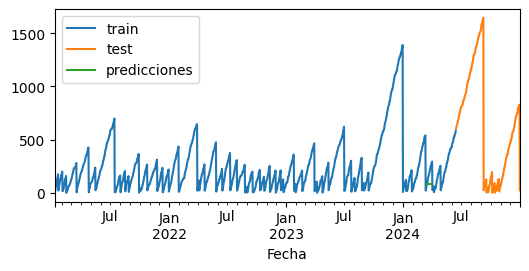

In [171]:
# Gráfico de predicciones vs valores reales

fig, ax = plt.subplots(figsize=(6, 2.5))
datos_train['Horas_Operativas'].plot(ax=ax, label='train')
datos_test['Horas_Operativas'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend()